# Training IndoBERT Sentiment Analysis (3 Classes)

## Objectives
- **Model:** `indobenchmark/indobert-base-p1`
- **Task:** Sentiment Classification
- **Optimization:** GPU (Mixed Precision fp16), Early Stopping, Best Model Loading
- **Target:** High Accuracy without Overfitting

In [2]:
# 1. Setup & Imports
import torch
import pandas as pd
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Check GPU
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'cpu'
print(f"Using Device: {device_name}")
if torch.cuda.is_available():
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Using Device: NVIDIA GeForce RTX 2050
VRAM: 4.00 GB


In [3]:
# 2. Load Data & Preprocessing
file_path = r'd:/Skripsi/sentiment-analyst-ojol-review/data/gojek_scraped_3class_RELABELED.csv'
df = pd.read_csv(file_path)

# Label Mapping
label_map = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['sentiment'].map(label_map)

# Split Data (Stratified to keep balance)
# 80% Train, 10% Validation, 10% Test
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'].tolist(), 
    df['label'].tolist(), 
    test_size=0.2, 
    stratify=df['label'], 
    random_state=42
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, 
    temp_labels, 
    test_size=0.5, 
    stratify=temp_labels, 
    random_state=42
)

print(f"Train Size: {len(train_texts)}")
print(f"Val Size:   {len(val_texts)}")
print(f"Test Size:  {len(test_texts)}")

Train Size: 16615
Val Size:   2077
Test Size:  2077


In [4]:
# 3. Tokenization
model_name = 'indobenchmark/indobert-base-p1'
tokenizer = BertTokenizer.from_pretrained(model_name)

def tokenize_data(texts, labels):
    encodings = tokenizer(texts, truncation=True, padding=True, max_length=128)
    dataset = []
    for i in range(len(texts)):
        item = {key: torch.tensor(val[i]) for key, val in encodings.items()}
        item['labels'] = torch.tensor(labels[i])
        dataset.append(item)
    return dataset

train_dataset = tokenize_data(train_texts, train_labels)
val_dataset = tokenize_data(val_texts, val_labels)
test_dataset = tokenize_data(test_texts, test_labels)

In [5]:
# 4. Metrics Function
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='macro')
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

In [6]:
# 5. Training Configuration
id2label = {0: 'negative', 1: 'neutral', 2: 'positive'}
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}

model = BertForSequenceClassification.from_pretrained(
    model_name, 
    num_labels=3, 
    id2label=id2label, 
    label2id=label2id
)

# TRAINING ARGUMENTS (Optimized)
training_args = TrainingArguments(
    output_dir='./results_3class_relabeled', # SAVE KE FOLDER BARU
    num_train_epochs=5,              # Max epochs (Early stopping will likely stop earlier)
    per_device_train_batch_size=16,  # 16 is standard for 6-8GB VRAM
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,   # Virtual batch size = 32
    learning_rate=2e-5,              # Low LR to prevent overfitting
    weight_decay=0.01,               # Regularization
    warmup_ratio=0.1,
    eval_strategy="epoch",     # Check val every epoch
    save_strategy="epoch",           # Save model every epoch
    load_best_model_at_end=True,     # ALWAYS load the best model found
    metric_for_best_model="accuracy",
    fp16=True,                       # GPU Acceleration (Mixed Precision)
    logging_dir='./logs_relabeled',
    logging_steps=50,
    dataloader_num_workers=0         # Set >0 if on Linux, 0 on Windows usually safer
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# 6. Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)] # Stop if no improve for 2 epochs
)

# START TRAINING
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.420400,0.433317,0.844006,0.843781,0.849766,0.847183
2,0.344800,0.363309,0.864227,0.862763,0.863998,0.864235
3,0.233200,0.407225,0.863746,0.862540,0.867000,0.865586
4,0.159100,0.479458,0.852672,0.850681,0.852512,0.851603


TrainOutput(global_step=2080, training_loss=0.34900843386466684, metrics={'train_runtime': 1187.1265, 'train_samples_per_second': 69.98, 'train_steps_per_second': 2.19, 'total_flos': 4371629435550720.0, 'train_loss': 0.34900843386466684, 'epoch': 4.0})

In [8]:
# 7. Evaluation on Test Set
print("Evaluating on Test Set...")
test_result = trainer.predict(test_dataset)
print(test_result.metrics)

Evaluating on Test Set...


{'test_loss': 0.3639439642429352, 'test_accuracy': 0.862782859894078, 'test_f1': 0.8607662718060148, 'test_precision': 0.8618001096838585, 'test_recall': 0.8616975839305748, 'test_runtime': 6.4005, 'test_samples_per_second': 324.507, 'test_steps_per_second': 10.155}


              precision    recall  f1-score   support

    negative       0.87      0.88      0.87       737
     neutral       0.78      0.84      0.81       605
    positive       0.94      0.86      0.90       735

    accuracy                           0.86      2077
   macro avg       0.86      0.86      0.86      2077
weighted avg       0.87      0.86      0.86      2077



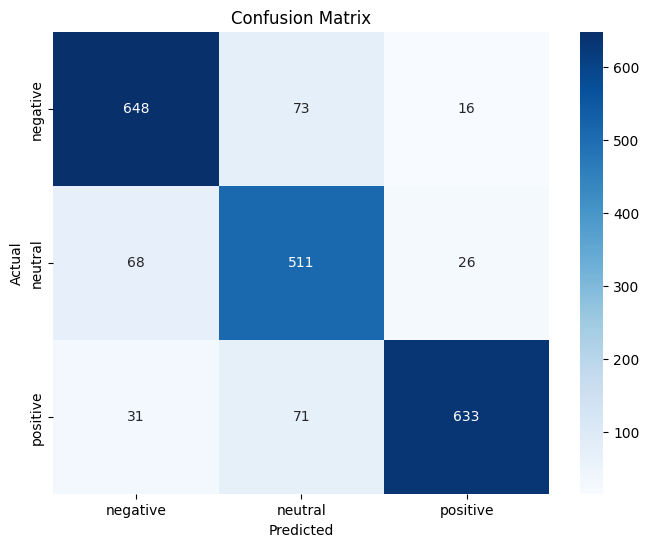

In [9]:
# 8. Confusion Matrix & Report
y_preds = np.argmax(test_result.predictions, axis=1)
y_true = test_result.label_ids

print(classification_report(y_true, y_preds, target_names=['negative', 'neutral', 'positive']))

# Plot CM
cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['negative', 'neutral', 'positive'], 
            yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [10]:
# 9. Save Final Model
save_path = './saved_model_indobert_3class_relabeled' # SAVE KE FOLDER BARU
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

Model saved to ./saved_model_indobert_3class_relabeled
